# Лабораторная работа №1 — EDA и визуализация

**Студент:** _ФИО_  
**Группа:** _группа_  
**Вариант:** 6

## Цель
Провести разведочный анализ данных: описательная статистика, визуализация распределений и анализ корреляций.


In [7]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from IPython.display import display


from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')


## 1. Загрузка и первичный осмотр датасета


In [8]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

display(df.head())
print('Размер датасета:', df.shape)
print('\nТипы данных:')
display(df.dtypes.to_frame('dtype'))


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Размер датасета: (150, 6)

Типы данных:


,dtype
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
target,int64
species,str


## 2. Основные статистические характеристики


In [9]:
num_cols = iris.feature_names
desc = df[num_cols].describe().T

display(desc)
(desc).to_csv(ART / 'describe_table.csv')


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


## 3. Визуальный анализ признаков


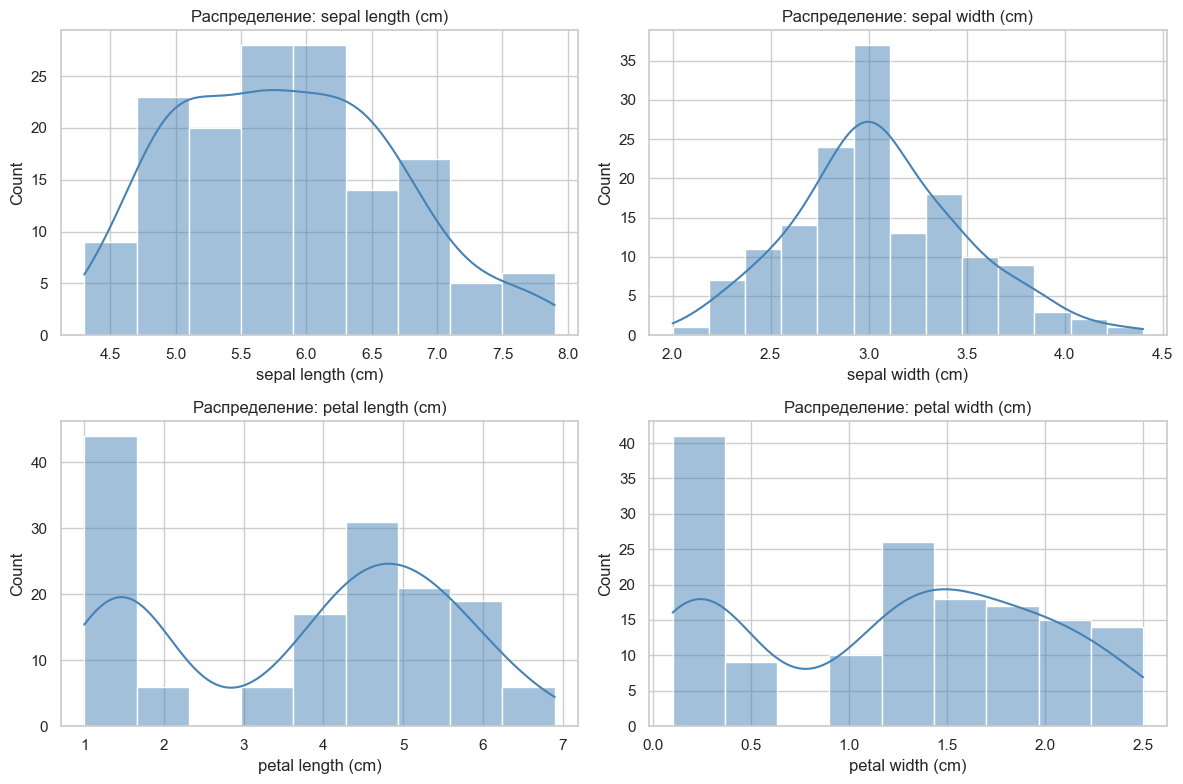

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Распределение: {col}')
plt.tight_layout()
plt.show()
fig.savefig(ART / 'distributions_inline.png', dpi=170, bbox_inches='tight')


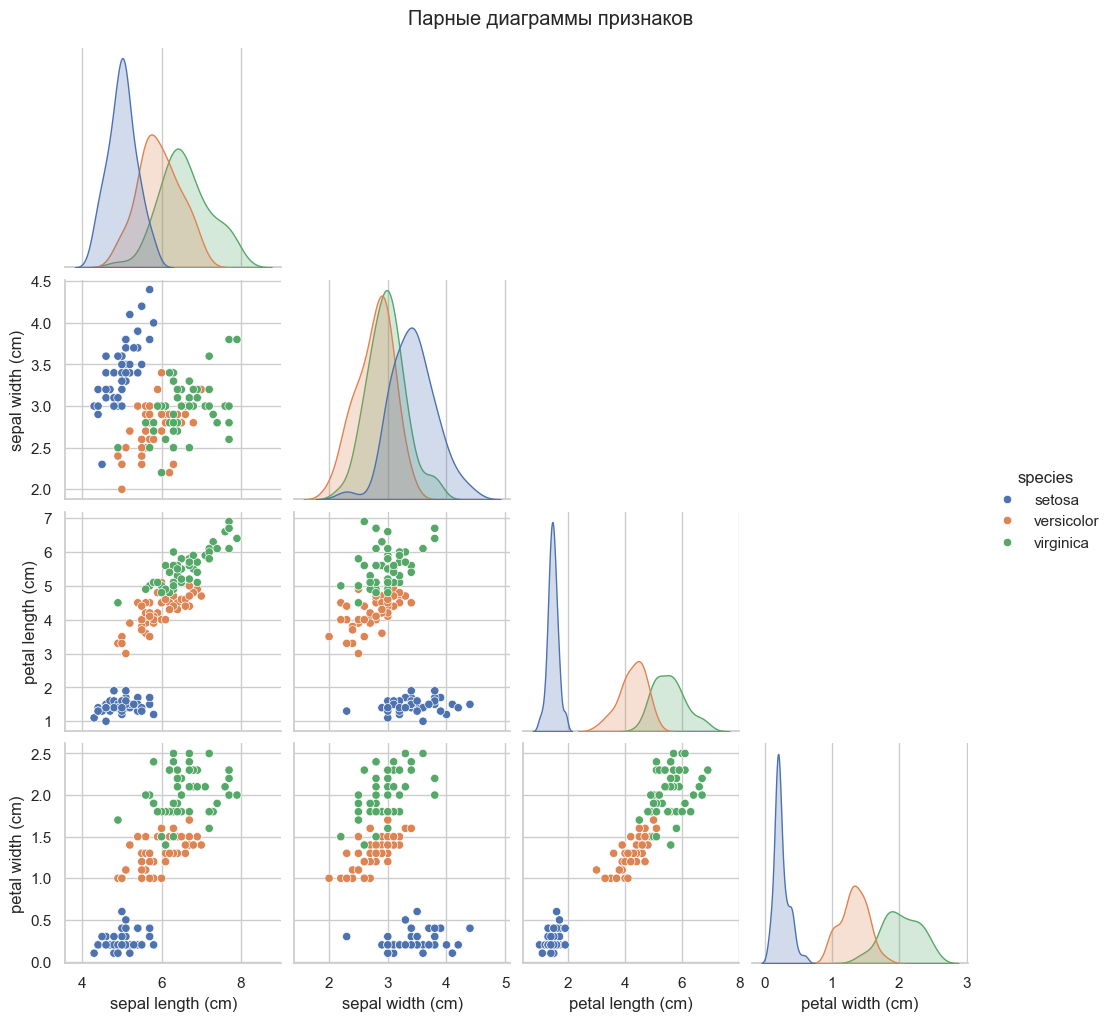

In [11]:
p = sns.pairplot(df, vars=num_cols, hue='species', corner=True)
p.fig.suptitle('Парные диаграммы признаков', y=1.02)
plt.show()
p.savefig(ART / 'pairplot_inline.png', dpi=170)


## 4. Корреляционный анализ


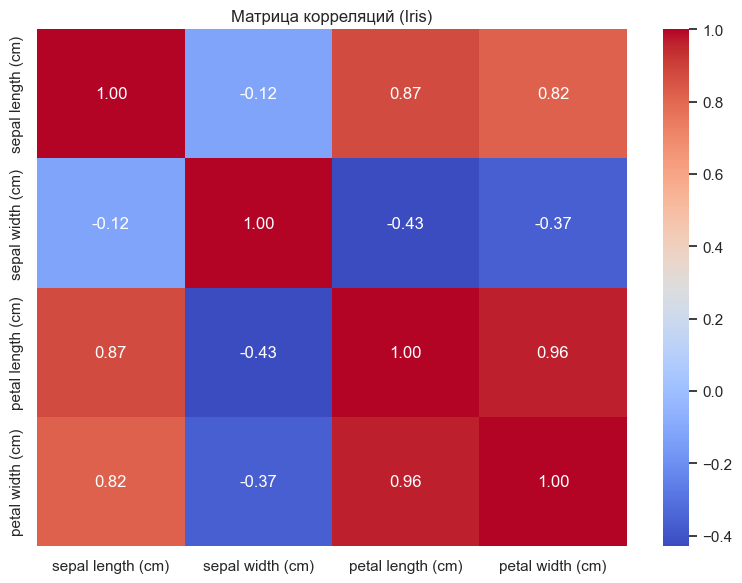

<Figure size 640x480 with 0 Axes>

In [12]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций (Iris)')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'correlation_heatmap_inline.png', dpi=170, bbox_inches='tight')

corr.to_csv(ART / 'correlation_matrix.csv')


## Выводы
- Датасет сбалансирован по классам и не содержит пропусков.
- Признаки `petal length` и `petal width` демонстрируют сильную положительную корреляцию.
- Для классификации классов Iris наиболее информативны признаки, связанные с параметрами лепестка.
